# Customer Churn Prediction Project

This project predicts whether a customer will leave a company or continue using the service.

We use historical customer data to train a machine learning model.

## Dataset

The dataset contains customer details such as:

- Age
- Total purchase amount
- Whether an account manager is assigned
- Number of years as customer
- Number of sites
- Churn status

## Goal

The goal is to predict:

- `1` = Customer will churn
- `0` = Customer will not churn

## Algorithm Used

Logistic Regression implemented from scratch using:

- Sigmoid function
- Cost function
- Gradient descent

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

In [2]:
df = pd.read_csv("customer_churn.csv")

df.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [3]:
df.shape

(900, 10)

In [4]:
df.columns

Index(['Names', 'Age', 'Total_Purchase', 'Account_Manager', 'Years',
       'Num_Sites', 'Onboard_date', 'Location', 'Company', 'Churn'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    str    
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    str    
 7   Location         900 non-null    str    
 8   Company          900 non-null    str    
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 154.0 KB


In [6]:
df.isnull().sum()

Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [7]:
df.describe()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [8]:
df["Churn"].value_counts()

Churn
0    750
1    150
Name: count, dtype: int64

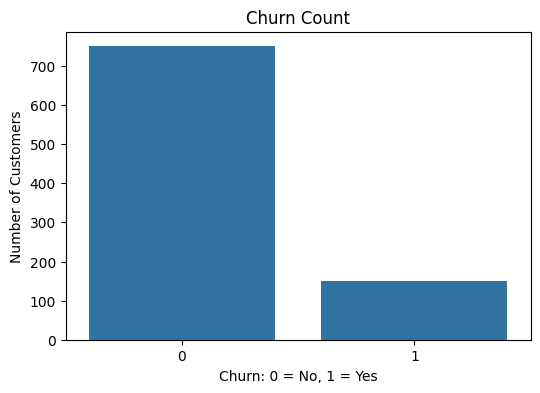

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Count")
plt.xlabel("Churn: 0 = No, 1 = Yes")
plt.ylabel("Number of Customers")
plt.show()

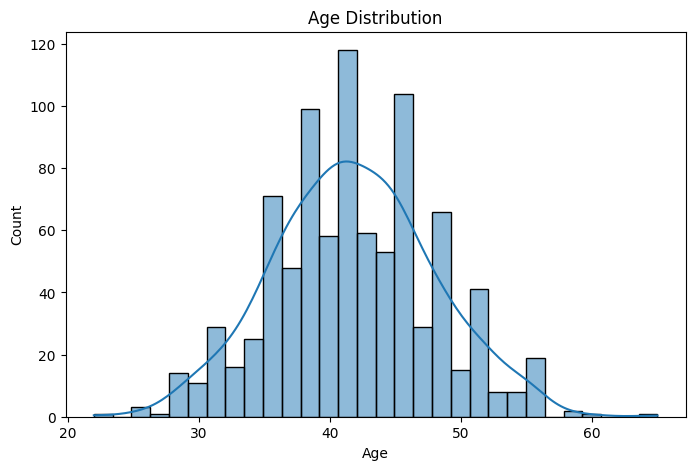

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

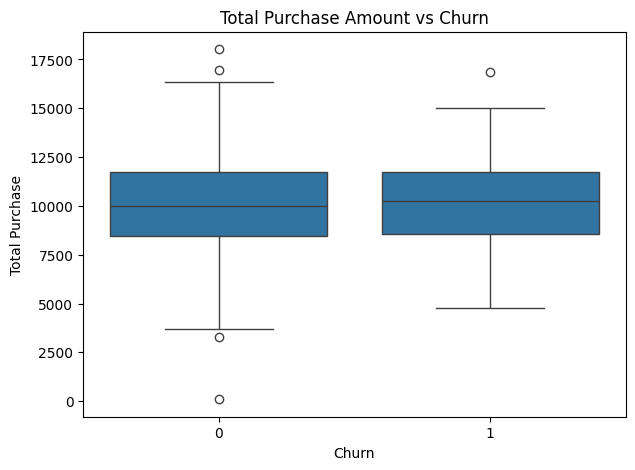

In [11]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="Total_Purchase")
plt.title("Total Purchase Amount vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Purchase")
plt.show()

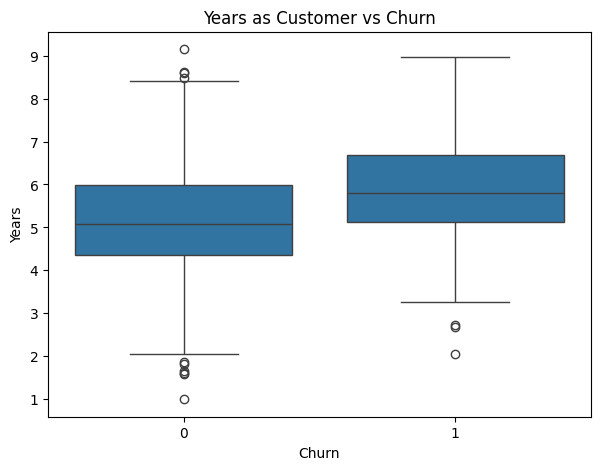

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="Years")
plt.title("Years as Customer vs Churn")
plt.xlabel("Churn")
plt.ylabel("Years")
plt.show()

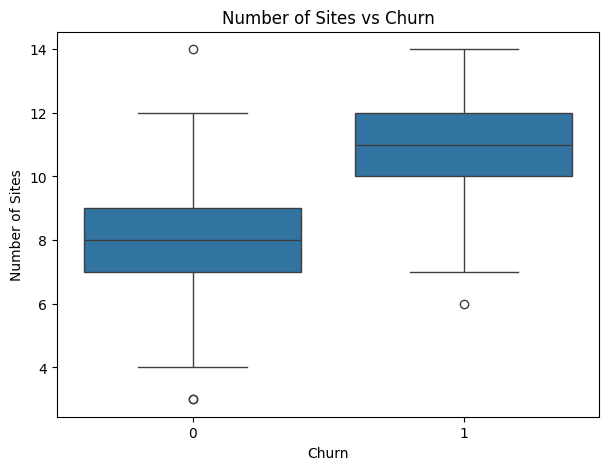

In [13]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Churn", y="Num_Sites")
plt.title("Number of Sites vs Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Sites")
plt.show()

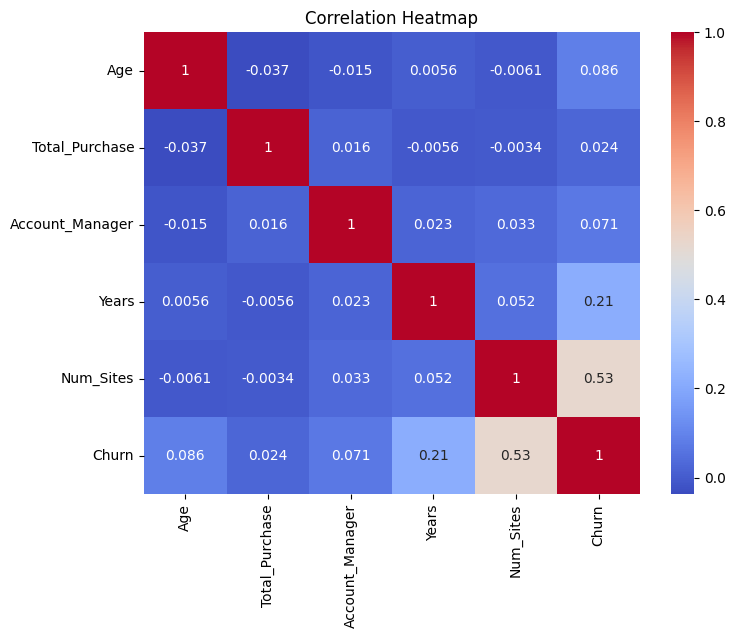

In [14]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [15]:
df_model = df.drop(["Names", "Location", "Company", "Onboard_date"], axis=1)

df_model.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
0,42.0,11066.80,0,7.22,8.0,1
1,41.0,11916.22,0,6.50,11.0,1
2,38.0,12884.75,0,6.67,12.0,1
3,42.0,8010.76,0,6.71,10.0,1
4,37.0,9191.58,0,5.56,9.0,1


In [16]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("Features:")
print(X.head())

print("Target:")
print(y.head())

Features:
    Age  Total_Purchase  Account_Manager  Years  Num_Sites
0  42.0        11066.80                0   7.22        8.0
1  41.0        11916.22                0   6.50       11.0
2  38.0        12884.75                0   6.67       12.0
3  42.0         8010.76                0   6.71       10.0
4  37.0         9191.58                0   5.56        9.0
Target:
0    1
1    1
2    1
3    1
4    1
Name: Churn, dtype: int64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (720, 5)
X_test shape: (180, 5)
y_train shape: (720,)
y_test shape: (180,)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_scaled = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

print(X_train_scaled[:5])

[[ 1.         -1.9404147   0.60925408  1.04547753 -0.04154568 -0.34942049]
 [ 1.         -0.2674431  -1.35541472  1.04547753 -0.7742027   1.35430017]
 [ 1.         -0.76933458  2.0391206  -0.95650071  1.28984181 -1.48523426]
 [ 1.          0.23444838 -1.70978122 -0.95650071  0.48628249 -0.34942049]
 [ 1.          0.73633986  0.59419833  1.04547753  2.09340112  0.78639328]]


In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [21]:
def cost_function(X, y, theta):
    m = len(y)
    
    h = sigmoid(X.dot(theta))
    
    # Avoid log(0) error
    h = np.clip(h, 1e-15, 1 - 1e-15)
    
    cost = -(1 / m) * np.sum(
        y * np.log(h) + (1 - y) * np.log(1 - h)
    )
    
    gradient = (1 / m) * X.T.dot(h - y)
    
    return cost, gradient

In [22]:
def gradient_descent(X, y, theta, learning_rate, iterations):
    cost_history = np.zeros(iterations)
    
    for i in range(iterations):
        cost, gradient = cost_function(X, y, theta)
        theta = theta - learning_rate * gradient
        cost_history[i] = cost
        
    return theta, cost_history

In [23]:
def predict_probability(X, theta):
    return sigmoid(X.dot(theta))


def predict_class(X, theta):
    probabilities = predict_probability(X, theta)
    return [1 if p >= 0.5 else 0 for p in probabilities]

In [24]:
theta_initial = np.zeros(X_train_scaled.shape[1])

learning_rate = 0.01
iterations = 1000

theta, cost_history = gradient_descent(
    X_train_scaled,
    y_train.values,
    theta_initial,
    learning_rate,
    iterations
)

print("Training completed")
print("Theta values:", theta)

Training completed
Theta values: [-1.44680705  0.11719844  0.04345911  0.11957212  0.3062018   0.91668112]


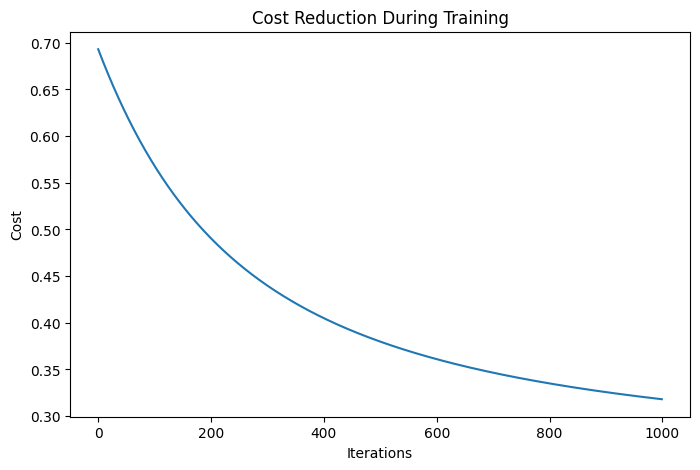

In [25]:
plt.figure(figsize=(8,5))
plt.plot(range(iterations), cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Reduction During Training")
plt.show()

In [26]:
y_pred = predict_class(X_test_scaled, theta)

y_pred[:10]

[0, 0, 0, 0, 1, 0, 0, 1, 1, 1]

In [27]:
accuracy = np.mean(y_test.values == y_pred) * 100

print("Model Accuracy:", round(accuracy, 2), "%")

Model Accuracy: 88.89 %


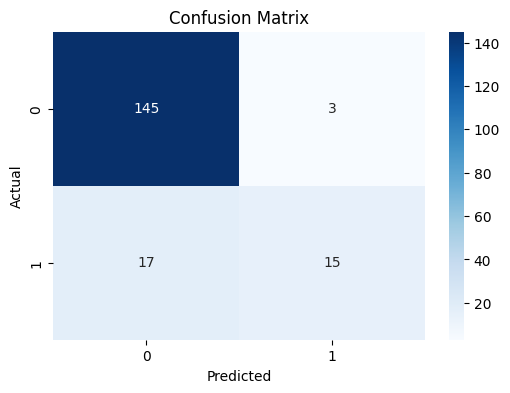

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       148
           1       0.83      0.47      0.60        32

    accuracy                           0.89       180
   macro avg       0.86      0.72      0.77       180
weighted avg       0.88      0.89      0.88       180



In [30]:
new_customers = pd.read_csv("new_customers_1.csv")

new_customers.head()

,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company
0,Andrew Mccall,37.0,9935.53,1,7.71,8.0,2011-08-29 18:37:54,38612 Johnny Stravenue Nataliebury WI 15717-8316,King Ltd
1,Michele Wright,23.0,7526.94,1,9.28,15.0,2013-07-22 18:19:54,"21083 Nicole Junction Suite 332, Youngport ME ...",Cannon-Benson
2,Jeremy Chang,65.0,100.00,1,1.00,15.0,2006-12-11 07:48:13,085 Austin Views Lake Julialand WY 63726-4298,Barron-Robertson
3,Megan Ferguson,32.0,6487.50,0,9.40,14.0,2016-10-28 05:32:13,922 Wright Branch North Cynthialand NC 64721,Sexton-Golden
4,Taylor Young,32.0,13147.71,1,10.00,8.0,2012-03-20 00:36:46,Unit 0789 Box 0734 DPO AP 39702,Wood LLC


In [31]:
customer_names = new_customers["Names"]

In [32]:
new_customers_model = new_customers.drop(
    ["Names", "Location", "Company", "Onboard_date"],
    axis=1
)

new_customers_model.head()

,Age,Total_Purchase,Account_Manager,Years,Num_Sites
0,37.0,9935.53,1,7.71,8.0
1,23.0,7526.94,1,9.28,15.0
2,65.0,100.00,1,1.00,15.0
3,32.0,6487.50,0,9.40,14.0
4,32.0,13147.71,1,10.00,8.0


In [35]:
new_customers_scaled = scaler.transform(new_customers_model)

new_customers_scaled = np.c_[
    np.ones((new_customers_scaled.shape[0], 1)),
    new_customers_scaled
]

In [36]:
new_probabilities = predict_probability(new_customers_scaled, theta)
new_predictions = predict_class(new_customers_scaled, theta)

results = pd.DataFrame({
    "Customer_Name": customer_names,
    "Churn_Probability": new_probabilities,
    "Predicted_Churn": new_predictions
})

results

,Customer_Name,Churn_Probability,Predicted_Churn
0,Andrew Mccall,0.241035,0
1,Michele Wright,0.928144,1
2,Jeremy Chang,0.777749,1
3,Megan Ferguson,0.879263,1
4,Taylor Young,0.346258,0
5,Jessica Drake,0.652650,1


In [37]:
results["Churn_Status"] = results["Predicted_Churn"].map({
    0: "Not Likely to Churn",
    1: "Likely to Churn"
})

results

,Customer_Name,Churn_Probability,Predicted_Churn,Churn_Status
0,Andrew Mccall,0.241035,0,Not Likely to Churn
1,Michele Wright,0.928144,1,Likely to Churn
2,Jeremy Chang,0.777749,1,Likely to Churn
3,Megan Ferguson,0.879263,1,Likely to Churn
4,Taylor Young,0.346258,0,Not Likely to Churn
5,Jessica Drake,0.652650,1,Likely to Churn


In [38]:
results.to_csv("new_customer_churn_predictions.csv", index=False)

print("Predictions saved successfully!")

Predictions saved successfully!
